In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings 
warnings.filterwarnings("ignore")

In [110]:
df=pd.read_csv(r"C:\Users\naray\Downloads\ai_job_trends_dataset.csv")
df

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,"Psychotherapist, dance movement",Education,Increasing,Moderate,142238.00,PhD,16,7816,1363,56.91,27.27,China,65.90
29996,"Scientist, water quality",IT,Decreasing,Moderate,123107.50,Associate Degree,19,9358,7632,27.25,12.84,UK,31.18
29997,Web designer,Manufacturing,Decreasing,Moderate,97305.51,Master’s Degree,0,9605,2559,31.76,16.82,China,26.07
29998,Primary school teacher,Entertainment,Increasing,Moderate,95599.22,High School,15,5481,4879,32.46,45.93,Brazil,40.43


In [111]:
df["Industry"].head()

0               IT
1    Manufacturing
2          Finance
3       Healthcare
4               IT
Name: Industry, dtype: object

In [112]:
#Find the percentage of industry are there in jobs 
Industry_Count = df["Industry"].value_counts().reset_index()
Industry_Count.columns = ["Industry", "Count"]

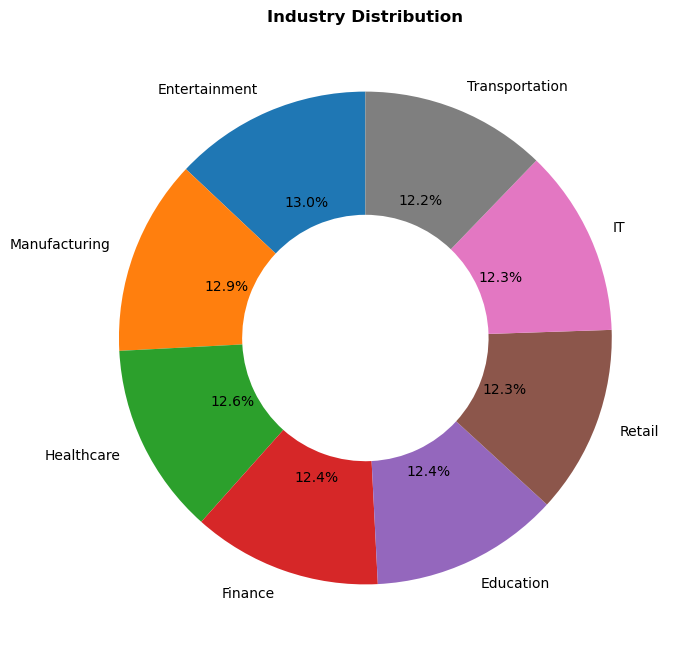

In [104]:
plt.figure(figsize=(8,8))

plt.pie(
    Industry_Count["Count"],
    labels=Industry_Count["Industry"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.5}
)

plt.title("Industry Distribution",color="black",fontweight="bold")
plt.show()

In [113]:
#Which location has the highest number of jobs?
Location_Count = df["Location"].value_counts().reset_index()
Location_Count.columns = ["Location", "Count"]

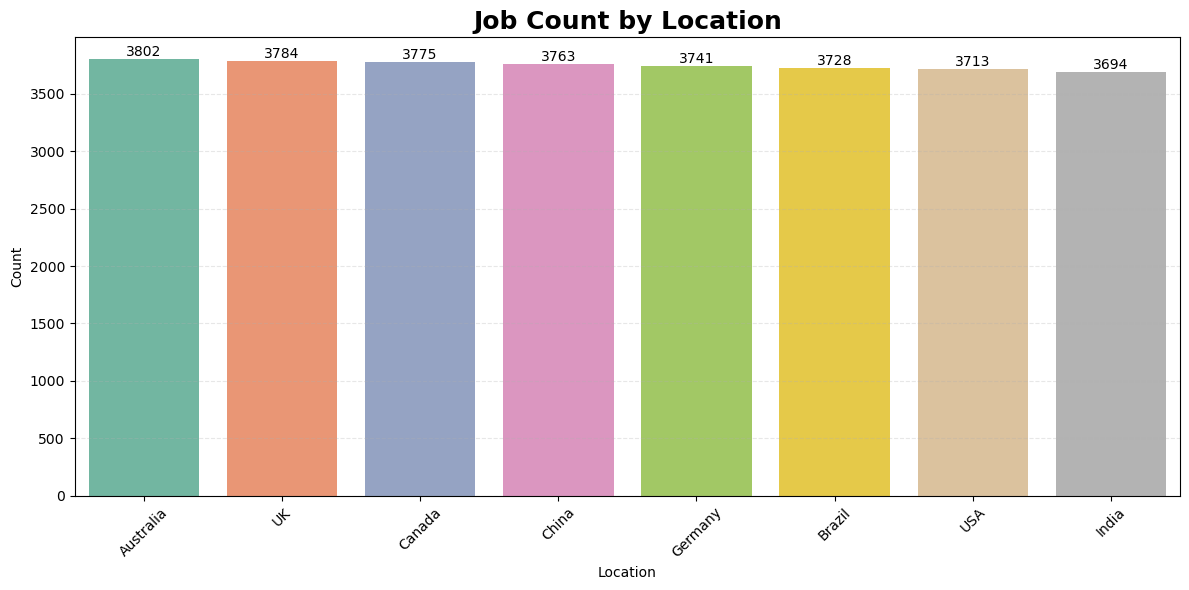

In [120]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=Location_Count,
    x="Location",
    y="Count",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Job Count by Location", fontsize=18, fontweight="bold")
plt.xlabel("Location")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 5. Which education level is most required?

In [121]:
df["Required Education"].value_counts()

Required Education
Bachelor’s Degree    6146
Master’s Degree      6097
Associate Degree     6003
High School          5900
PhD                  5854
Name: count, dtype: int64

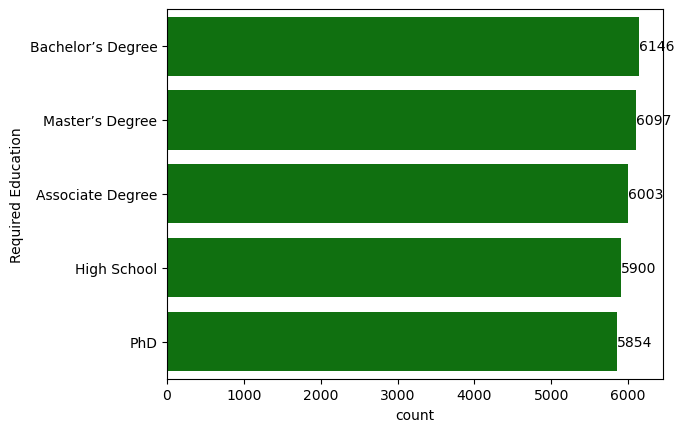

In [127]:
ax=sns.countplot(
    data=df,
    y="Required Education",
    order=df["Required Education"].value_counts().index,color="green"
)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.show()

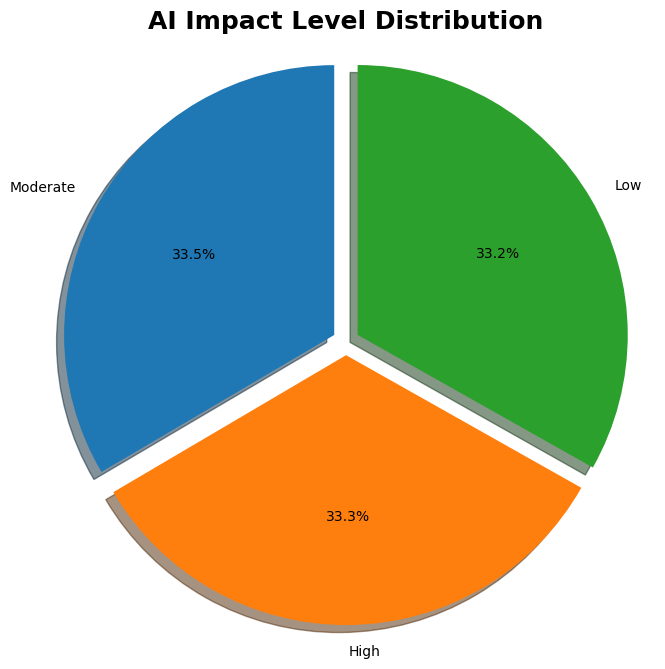

In [132]:
AI_Impact = df["AI Impact Level"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    AI_Impact,
    labels=AI_Impact.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05]*len(AI_Impact),
    shadow=True
)

plt.title("AI Impact Level Distribution", fontsize=18, fontweight="bold")

plt.axis("equal")
plt.show()

In [136]:
job_openings=df.groupby("Industry")["Projected Openings (2030)"].sum()
job_openings.columns=["Industry","Job_Openings"]
job_openings

Industry
Education         18654812
Entertainment     20041578
Finance           18765438
Healthcare        19414873
IT                18831630
Manufacturing     19605328
Retail            18576066
Transportation    18336818
Name: Projected Openings (2030), dtype: int64

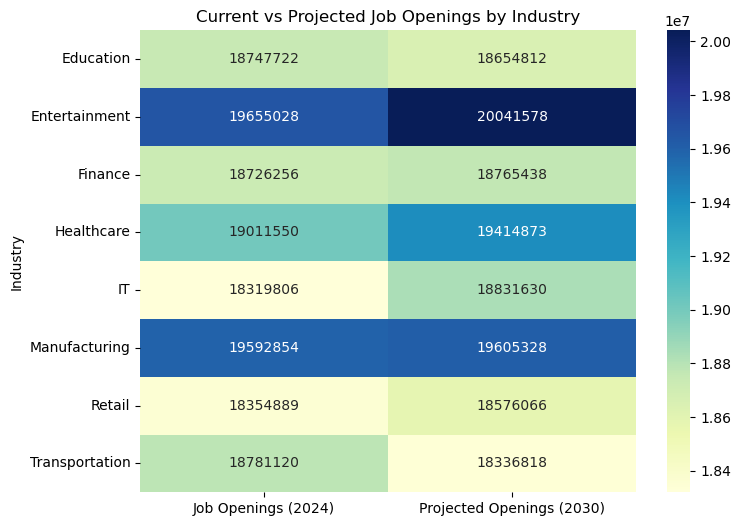

In [137]:
heatmap_data = df.groupby("Industry")[[
    "Job Openings (2024)",
    "Projected Openings (2030)"
]].sum()

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title("Current vs Projected Job Openings by Industry")
plt.show()

In [143]:
Top_10_Risk = df.sort_values(
    by="Automation Risk (%)",
    ascending=False
)[["Job Title", "Automation Risk (%)"]].head(10)

Top_10_Risk

,Job Title,Automation Risk (%)
18947,Meteorologist,99.99
14665,Fast food restaurant manager,99.99
3287,"Engineer, electrical",99.98
26124,Advertising art director,99.98
3691,"Designer, multimedia",99.98
12714,Water engineer,99.98
6539,"Teacher, adult education",99.97
3147,"Conservator, museum/gallery",99.97
3808,"Surveyor, insurance",99.97
14757,Medical laboratory scientific officer,99.97


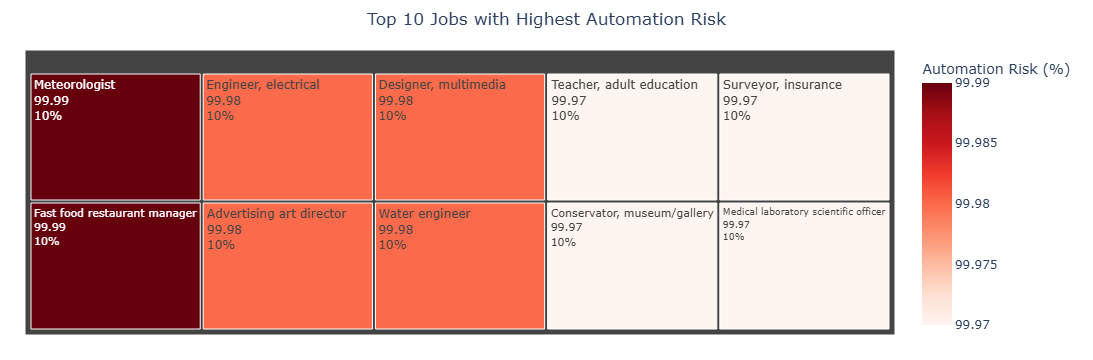

In [141]:
fig = px.treemap(
    Top_10_Risk,
    path=["Job Title"],
    values="Automation Risk (%)",
    color="Automation Risk (%)",
    color_continuous_scale="Reds",
    title="Top 10 Jobs with Highest Automation Risk"
)

fig.update_traces(
    textinfo="label+value+percent entry"
)

fig.update_layout(
    title_x=0.5,
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()

In [148]:
Top_10_Safe = df.sort_values(
    by="Automation Risk (%)",
    ascending=True
)[["Job Title", "Automation Risk (%)"]].head(10)

Top_10_Safe

,Job Title,Automation Risk (%)
9571,Armed forces logistics/support/administrative ...,0.00
22104,Sports development officer,0.00
29215,"Designer, jewellery",0.01
4047,"Scientist, clinical (histocompatibility and im...",0.02
29234,Art therapist,0.03
17496,Insurance underwriter,0.03
28239,Clinical biochemist,0.04
14346,Banker,0.05
22469,Civil Service fast streamer,0.05
19053,Electrical engineer,0.06


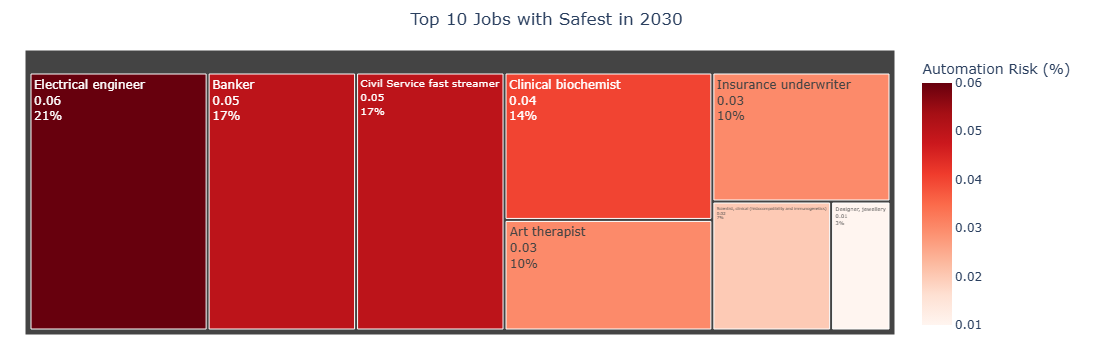

In [149]:
fig = px.treemap(
    Top_10_Risk,
    path=["Job Title"],
    values="Automation Risk (%)",
    color="Automation Risk (%)",
    color_continuous_scale="Reds",
    title="Top 10 Jobs with Safest in 2030"
)

fig.update_traces(
    textinfo="label+value+percent entry"
)

fig.update_layout(
    title_x=0.5,
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()

In [150]:
Top_10_Safe_Jobs = (
    df[
        (df["Location"] == "India") &
        (df["Industry"] == "IT")
    ][["Job Title", "Automation Risk (%)"]]
    .sort_values(by="Automation Risk (%)", ascending=True)
    .head(10)
)

Top_10_Safe_Jobs

,Job Title,Automation Risk (%)
23433,Tourist information centre manager,0.11
24923,Futures trader,0.11
23866,"Journalist, magazine",0.26
13988,English as a foreign language teacher,0.27
13968,Insurance claims handler,0.51
22444,"Pilot, airline",0.56
27964,"Engineer, communications",0.66
21107,"Psychotherapist, child",1.00
17243,Statistician,1.14
29408,Ceramics designer,1.20


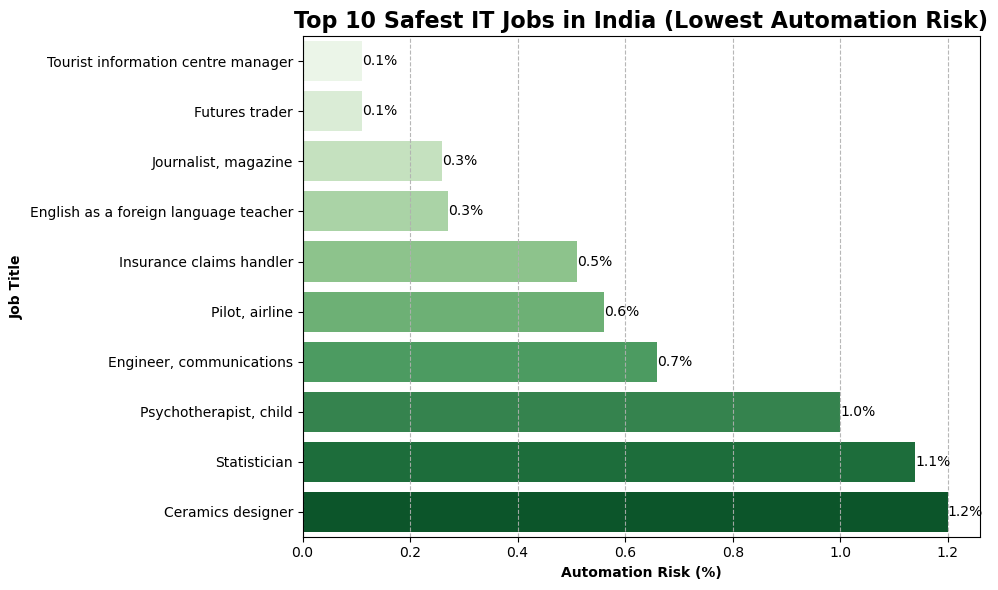

In [154]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Top_10_Safe_Jobs,
    x="Automation Risk (%)",
    y="Job Title",
    palette="Greens"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Top 10 Safest IT Jobs in India (Lowest Automation Risk)",
          fontsize=16, fontweight="bold")

plt.xlabel("Automation Risk (%)",fontweight="bold")
plt.ylabel("Job Title",fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.9)

plt.tight_layout()
plt.show()

In [155]:
#Which education level gets the highest salary?

In [158]:
education_salary = (
    df.groupby("Required Education")["Median Salary (USD)"]
      .mean()
      .sort_values(ascending=True)
      .reset_index()
)
education_salary

,Required Education,Median Salary (USD)
0,Bachelor’s Degree,89690.314614
1,Associate Degree,89783.005707
2,High School,89949.569312
3,PhD,90366.780231
4,Master’s Degree,90812.747559


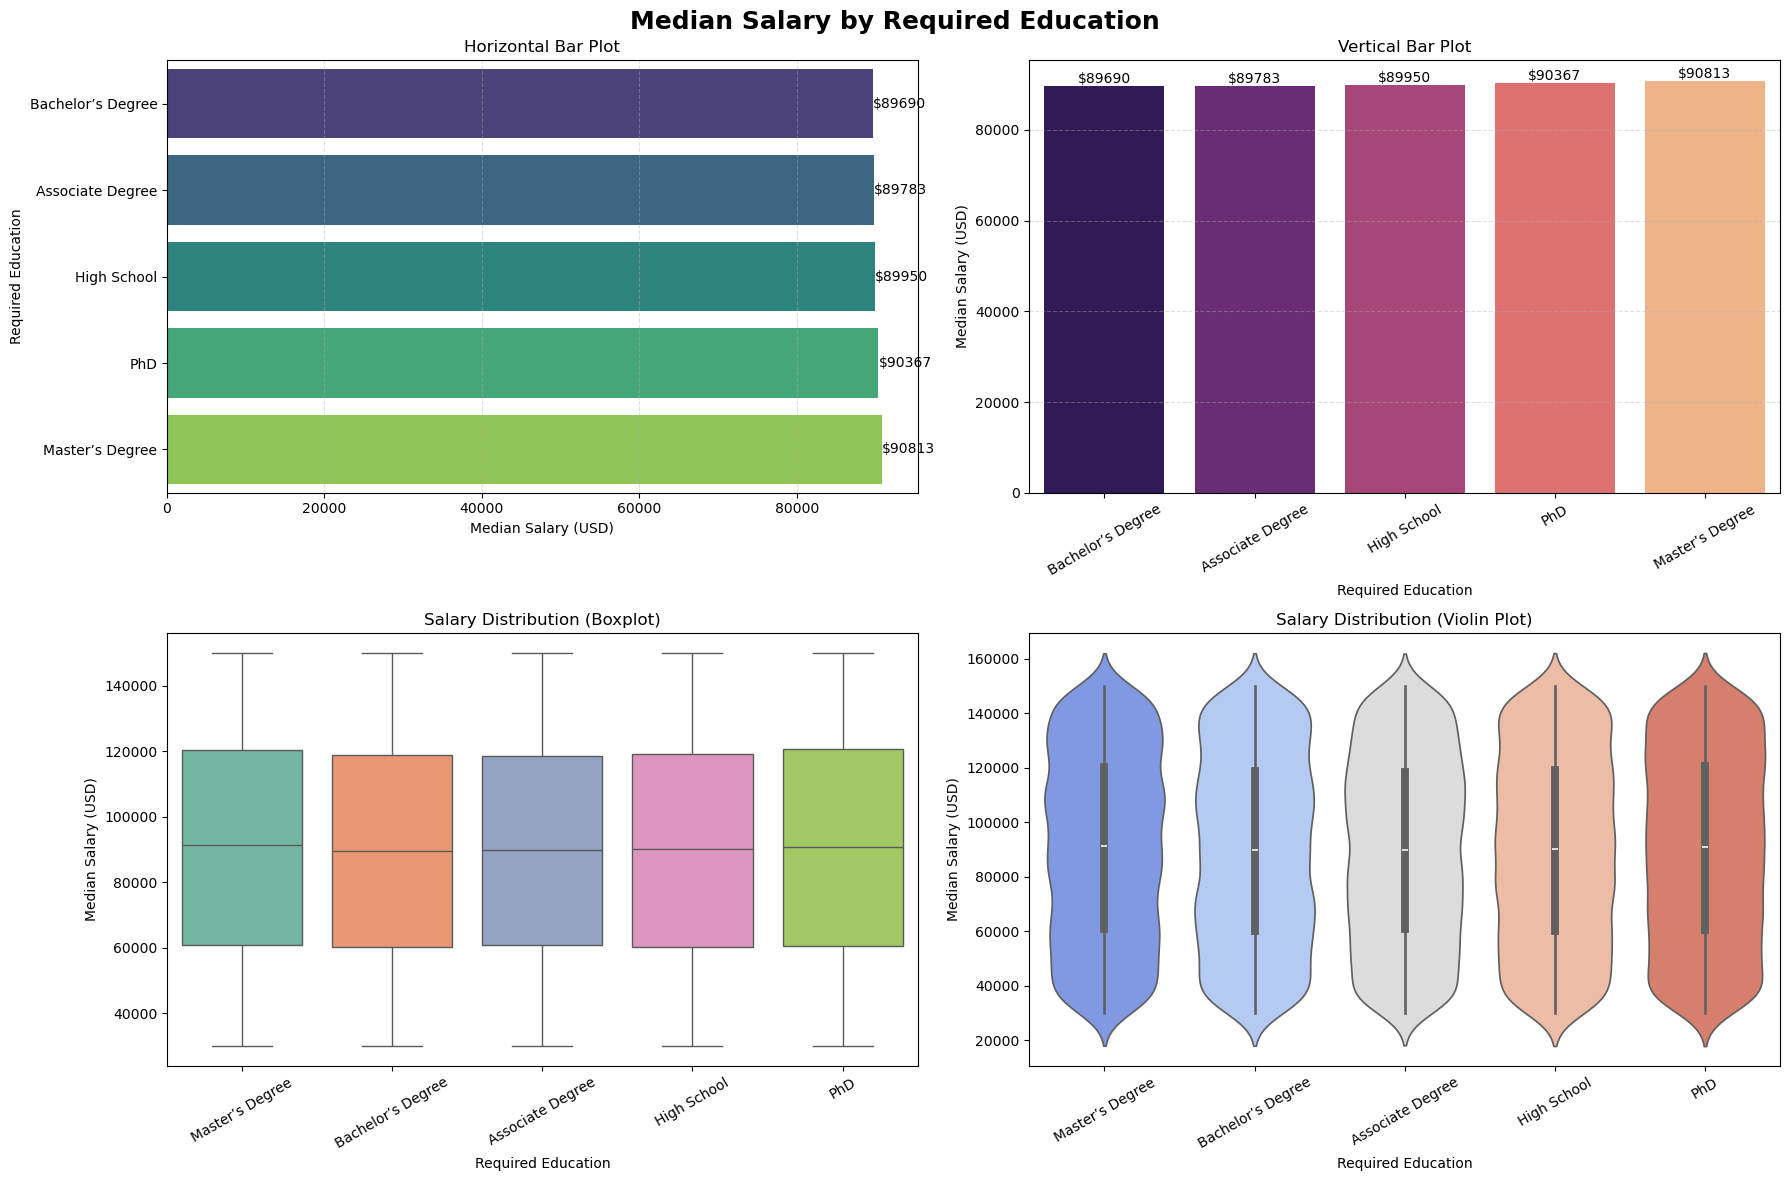

In [161]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax1 = sns.barplot(
    data=education_salary,
    x="Median Salary (USD)",
    y="Required Education",
    palette="viridis",
    ax=axes[0,0]
)

for container in ax1.containers:
    ax1.bar_label(container, fmt="$%.0f")

ax1.set_title("Horizontal Bar Plot")
ax1.grid(axis="x", linestyle="--", alpha=0.4)
 
ax2 = sns.barplot(
    data=education_salary,
    x="Required Education",
    y="Median Salary (USD)",
    palette="magma",
    ax=axes[0,1]
)

for container in ax2.containers:
    ax2.bar_label(container, fmt="$%.0f")

ax2.set_title("Vertical Bar Plot")
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

sns.boxplot(
    data=df,
    x="Required Education",
    y="Median Salary (USD)",
    palette="Set2",
    ax=axes[1,0]
)

axes[1,0].set_title("Salary Distribution (Boxplot)")
axes[1,0].tick_params(axis='x', rotation=30)

sns.violinplot(
    data=df,
    x="Required Education",
    y="Median Salary (USD)",
    palette="coolwarm",
    ax=axes[1,1]
)

axes[1,1].set_title("Salary Distribution (Violin Plot)")
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle(
    "Median Salary by Required Education",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [162]:
df

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,"Psychotherapist, dance movement",Education,Increasing,Moderate,142238.00,PhD,16,7816,1363,56.91,27.27,China,65.90
29996,"Scientist, water quality",IT,Decreasing,Moderate,123107.50,Associate Degree,19,9358,7632,27.25,12.84,UK,31.18
29997,Web designer,Manufacturing,Decreasing,Moderate,97305.51,Master’s Degree,0,9605,2559,31.76,16.82,China,26.07
29998,Primary school teacher,Entertainment,Increasing,Moderate,95599.22,High School,15,5481,4879,32.46,45.93,Brazil,40.43
